In [1]:

import torch
import torch.nn as nn
import torchvision.transforms as tf
import torchmetrics
from torchmetrics import StructuralSimilarityIndexMeasure
from torchvision.transforms.functional import center_crop as cc
import cv2
import pandas as pd
from sklearn import preprocessing as pre
import imageio
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.patches as patches
import plotly.graph_objects as go

import plotly.io as pio
import numpy as np
import math
import h5py
from PIL import Image
import copy
import os
import json
import torch.nn.functional as F
import torchvision.transforms.functional as f
import matplotlib.pyplot as plt
from matplotlib import cm
plt.rcParams['figure.figsize'] = (10,15)
device = torch.device('cuda')



# RMSE computation from IDW interpolation: KITTI

In [12]:
def inverse_distance_weighted(k1, power):
    kernel = np.empty((k1,k1))
    center = np.array((0,0))
    kernel = []
    weights = []
    
    for value in power:
        kernel = []
        for x_axis in np.arange(-(k1-1)/2, (k1+1)/2, 1):
            dist = []
            for y_axis in np.arange((k1-1)/2,-(k1+1)/2, -1):
                d = np.linalg.norm(center - np.array((x_axis, y_axis)))
                if d != 0:
                    weight = 1/(d**value)
                else:
                    weight = 0
                dist.append(weight)
            kernel.append(dist)
            
        # changing to tensor and reshaping it
        kernel_tensor = torch.tensor(np.array(kernel).astype(dtype = np.float32))
        kernel_tensor = kernel_tensor.unsqueeze(0).unsqueeze(1)
    
        # adding the tensor to a list
        weights.append(kernel_tensor)
        
    weights = torch.stack(weights).squeeze(1) # removing the extra channel
    return weights.to(device = 'cuda')

# ==============================================================================================================================================
def evaluate(output, target):
    
    '''
    valid_mask = target > 0
    # convert from meters to mm
    output_mm = 1e3 * output[valid_mask]
    target_mm = 1e3 * target[valid_mask]
    '''
    valid_mask = (target > 0).float()
    # convert from meters to mm
    output_mm = 1e3 * (output*valid_mask)
    target_mm = 1e3 * (target*valid_mask)
  

    abs_diff = (output_mm - target_mm).abs()
    mse = float((torch.pow(abs_diff, 2)).sum().cpu().numpy())/valid_mask.cpu().numpy().sum()
    rmse = math.sqrt(mse)
    mae = float(abs_diff.mean())
   
    ssim = StructuralSimilarityIndexMeasure(reduction='sum').to(device = 'cuda')
    ssim_error = ssim(output_mm,target_mm).detach().cpu().numpy()
    ssim_error = ssim_error/valid_mask.cpu().numpy().sum()
 
    return rmse, mae, ssim_error
#====================================================================================================================================================
class IDW(nn.Module):
    def __init__(self, w):
        super().__init__()

        self.weight = w

        self.conv1 = nn.Conv2d(1, 10, 21, stride=1, bias = False, padding = 'same', dilation=1)
        self.conv1.weight = nn.Parameter(self.weight, requires_grad=False)
        self.max_pool1 = nn.MaxPool2d(
            21, 
            stride=1, 
            padding=21//2)
        
    def forward(self, x, mask):
        conv_x = self.conv1(x)
        normalizer = self.conv1(mask)
        normalizer[normalizer==0] = -1
        normalizer = 1/normalizer
        normalizer[normalizer==-1] = 0
        conv_x = conv_x * normalizer
        conv_x = x + (1-mask)*conv_x
        return conv_x
    

#==================================================================================================================================================
power = np.linspace(2.0, 4.5, num=10)
weight =  inverse_distance_weighted(21, power)
model = IDW(weight).to(device='cuda')
rmse_total =[]
mae_total = []
ssim_total = []
with open('/data//Datasets/test.txt' ) as xh:
    lines = xh.readlines()
    for line in range(len(lines)):
        line_split = str(lines[line]).split('\t')
        path1= line_split[0].strip()
        path2 = line_split[1].strip()

        data1 = cv2.imread(path1,  cv2.IMREAD_ANYDEPTH)
        data1 = data1.astype(float)/256.0
        
        
        # sparsifying the data with different sparsity level
        
        mask = (data1>0).astype(float)
        for i in np.arange(0,mask.shape[0], 32, dtype = int):
            for j in np.arange(0, mask.shape[1], 32, dtype=int):
                # slicing a patch of size 9x18 from the mask
                patch = mask[i:(i+32), j:(j+32)]
                #count the number of ones in the patch and abandon 40% of depth points, i.e, selecting only 60% of them(60% rate)
                num_replaced = int(np.count_nonzero(patch) * (80/100))
           
                # storing iindices all ones in the patch
                indices = np.where(patch ==1)

                # if all the elements in the patch are zero, do nothing
                np.random.seed(42)
                if num_replaced>0: 
                    indices_x = []
                    indices_y = []
    
                    indices_random = np.arange(0, len(indices[0]))
                    p_range = np.arange(1, len(indices[0])+1)
                    prob = np.random.dirichlet(p_range, 1)[0]
                
                    indices_choosen = np.random.choice(indices_random, num_replaced, replace=False, p=prob)
                    for k in(indices_choosen):
                        indices_x.append(indices[0][k])
                        indices_y.append(indices[1][k])
                    
                    patch[indices_x, indices_y] = 0
                    mask[i:(i+32), j:(j+32)] = patch    
        data1 = data1 * mask
    
        data1 = torch.tensor(data1).unsqueeze(0).unsqueeze(0)
        data1 = data1.to(dtype = torch.float32).to(device = 'cuda')
        label = cv2.imread(path2,cv2.IMREAD_ANYDEPTH)
        label = label.astype(float)/256.0
        label = torch.tensor(label).unsqueeze(0).unsqueeze(0).to(device='cuda')
    
        mask_input = (data1>0).to(dtype = torch.float32).to(device='cuda')
        output = model(data1, mask_input)

  
        for j in range(output.shape[1]):
            #print(output[0,j,:].shape, label.shape)
            
            if line ==0:
                rmse, mae,ssim_error = evaluate(output[0,j,:].unsqueeze(0).unsqueeze(0),label)
        
                ssim_total.append(ssim_error)
                rmse_total.append(rmse)
                mae_total.append(mae)
        

             
            else:
                rmse, mae,ssim_error = evaluate(output[0,j,:].unsqueeze(0).unsqueeze(0),label)
                
                ssim_error = ssim_total[j] + ssim_error
                ssim_total[j] = ssim_error

                rmse = rmse_total[j] + rmse
                rmse_total[j] = rmse
                
                mae = mae_total[j] + mae
                mae_total[j] = mae

np.array(rmse_total)

array([3472034.71105769, 3471587.8943441 , 3473650.2627528 ,
       3477415.06659843, 3482296.64629928, 3487880.17577676,
       3493874.67809064, 3500076.80720196, 3506344.96263318,
       3512581.05163948])

In [7]:
'''
# ploting training /validation loss
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(1, 1, 1)
power = np.linspace(0.5, 12.0, num=16).round(2)
# taking the average
ax.plot(power, np.array(rmse_total)/1000, color='black',  linewidth=1.0)
#ax.plot(power, np.sqrt(np.array(mae_total)/1000), linewidth=1.0,color='r', label ='MAE' )

    
plt.xlabel('power value')
plt.ylabel('RMSE [mm]')
# Hide the right and top spines
power = np.linspace(0.5, 12.0, num=16).round(2)
ax.set_xticks(power, labels=power)

ax.spines[['right', 'top']].set_visible(False)
plt.title('31x31 kernel')
#plt.savefig('power_rmse', format= 'eps' )
#plt.legend(loc='upper center')

'''

"\n# ploting training /validation loss\nfig = plt.figure(figsize=(10,4))\nax = fig.add_subplot(1, 1, 1)\npower = np.linspace(0.5, 12.0, num=16).round(2)\n# taking the average\nax.plot(power, np.array(rmse_total)/1000, color='black',  linewidth=1.0)\n#ax.plot(power, np.sqrt(np.array(mae_total)/1000), linewidth=1.0,color='r', label ='MAE' )\n\n    \nplt.xlabel('power value')\nplt.ylabel('RMSE [mm]')\n# Hide the right and top spines\npower = np.linspace(0.5, 12.0, num=16).round(2)\nax.set_xticks(power, labels=power)\n\nax.spines[['right', 'top']].set_visible(False)\nplt.title('31x31 kernel')\n#plt.savefig('power_rmse', format= 'eps' )\n#plt.legend(loc='upper center')\n\n"

# RMSE value for IDW convolution for different sparsity


In [13]:
percent_0 =[1892591.42108697, 1887209.31546259, 1890588.30434676,
       1899687.39507136, 1911919.03417905, 1925457.05369507,
       1939168.85651497, 1952423.30242486, 1964909.50229005,
       1976505.12805471]

percent_20 = [1933556.49513163, 1931863.43071153, 1937983.59327545,
       1948910.62856556, 1962278.53782936, 1976505.92578518,
       1990650.99767331, 2004206.87199529, 2016934.23364293,
       2028748.11863284]

percent_40 = [2011374.83501801, 2013149.48070173, 2021449.97904789,
       2033574.81775251, 2047548.92751047, 2062099.71114699,
       2076476.53445237, 2090270.65629486, 2103282.72855567,
       2115436.5224865 ]

percent_60 = [2169806.09453849, 2172069.137223  , 2179572.77766429,
       2190246.74034676, 2202615.83280804, 2215705.95143766,
       2228904.29319335, 2241840.38781284, 2254300.79157428,
       2266171.95693758]

percent_80 = [3472034.71105769, 3471587.8943441 , 3473650.2627528 ,
       3477415.06659843, 3482296.64629928, 3487880.17577676,
       3493874.67809064, 3500076.80720196, 3506344.96263318,
       3512581.05163948]
channel =  list(np.linspace(2.0, 4.5, num=10).round(2))
p = ['0%']*10
points = np.append(p, [['20%']*10, ['40%']*10, ['60%']*10, ['80%']*10])
pixels = np.append(percent_0, [percent_20,percent_40,percent_60, percent_80])
#pixel = np.array(pixels).reshape(-1,1)
pixel = (np.array(pixels)/1000).round(2)
#normalize all values to be between 0 and 1
#pixel_norm = pre.MinMaxScaler().fit_transform(pixel)
channels = channel*5

In [14]:
min = []
min.append(np.array(percent_0).min())
min.append(np.array(percent_20).min())
min.append(np.array(percent_40).min())
min.append(np.array(percent_60).min())
min.append(np.array(percent_80).min())
    

In [4]:
(np.array(min)/1000).round(2)

array([1887.21, 1752.51, 2006.27, 2169.68, 3467.73])

In [6]:
1887.21, 2.28     1752.51,2.83   2006.27,2.0   2169.68, 2.0   3467.73, 2.2

[2.0, 2.28, 2.56, 2.83, 3.11, 3.39, 3.67, 3.94, 4.22, 4.5]

In [7]:
pixel 

array([1892.59, 1887.21, 1890.59, 1899.69, 1911.92, 1925.46, 1939.17,
       1952.42, 1964.91, 1976.51, 1816.54, 1773.47, 1755.09, 1752.51,
       1758.76, 1769.38, 1781.79, 1794.63, 1807.17, 1819.1 , 2006.27,
       2007.76, 2015.82, 2027.76, 2041.6 , 2056.05, 2070.36, 2084.12,
       2097.11, 2109.27, 2169.68, 2171.9 , 2179.37, 2189.99, 2202.31,
       2215.35, 2228.49, 2241.37, 2253.77, 2265.58, 3468.22, 3467.73,
       3469.77, 3473.53, 3478.42, 3484.01, 3490.03, 3496.26, 3502.56,
       3508.83])

In [15]:
pixel 

array([1892.59, 1887.21, 1890.59, 1899.69, 1911.92, 1925.46, 1939.17,
       1952.42, 1964.91, 1976.51, 1933.56, 1931.86, 1937.98, 1948.91,
       1962.28, 1976.51, 1990.65, 2004.21, 2016.93, 2028.75, 2011.37,
       2013.15, 2021.45, 2033.57, 2047.55, 2062.1 , 2076.48, 2090.27,
       2103.28, 2115.44, 2169.81, 2172.07, 2179.57, 2190.25, 2202.62,
       2215.71, 2228.9 , 2241.84, 2254.3 , 2266.17, 3472.03, 3471.59,
       3473.65, 3477.42, 3482.3 , 3487.88, 3493.87, 3500.08, 3506.34,
       3512.58])

In [155]:
df1 = pd.DataFrame()
df1['Power value'] = channels
df1['RMSE [mm]'] = pixel
df1['Sparsity level'] = points

fig = px.line(df1, x="Power value", y="RMSE [mm]", color='Sparsity level', width=600, height=400)

fig.add_annotation(text="x",
                  x=2.83, y=1704.26, showarrow=False)
fig.add_annotation(text="x",
                  x=2.83, y=1752.51, showarrow=False)
fig.add_annotation(text="x",
                  x=2.56, y=1824.93, showarrow=False)
fig.add_annotation(text="x",
                  x=2.56, y=1957.58, showarrow=False)
fig.add_annotation(text="x",
                  x=2.83, y=2298.6, showarrow=False)
fig.update_layout(
    xaxis = dict(
        tickmode = 'linear',
        tick0 = 0.5,
        dtick = 1
    )
)

fig.show()

In [123]:
pixel 

array([1775.11, 1749.69, 1741.43, 1744.4 , 1753.66, 1765.91, 1779.18,
       1792.41, 1805.08, 1816.95, 1811.68, 1790.61, 1785.3 , 1790.02,
       1800.25, 1813.03, 1826.64, 1840.14, 1853.05, 1865.17, 1881.85,
       1865.23, 1862.38, 1868.16, 1878.74, 1891.64, 1905.37, 1919.08,
       1932.31, 1944.85, 2014.02, 1998.86, 1995.11, 1998.89, 2007.3 ,
       2018.37, 2030.78, 2043.7 , 2056.61, 2069.2 , 2408.5 , 2392.62,
       2384.61, 2382.44, 2384.52, 2389.59, 2396.74, 2405.27, 2414.67,
       2424.57])

In [127]:
array([1741.43, 1785.3 , 1862.38, 1995.11, 2382.44])

[2.0, 2.28, 2.56, 2.83, 3.11, 3.39, 3.67, 3.94, 4.22, 4.5]

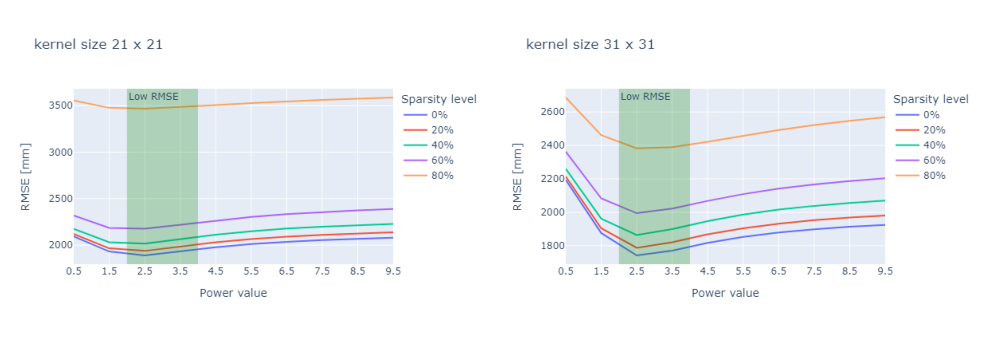

In [91]:
# concatenating the two images
fig = plt.figure(figsize=(10,4))
row = 1
col = 2
fig.add_subplot(row, col, 1)
rmse = plt.imread('2121.png')
plt.imshow(rmse)
#fig.axes[0].set_xlabel("Depth points randomly abandoned")
plt.axis('off')
plt.tight_layout()
fig.add_subplot(row, col, 2)
mae = plt.imread('3131.png')
plt.imshow(mae)
plt.axis('off')
plt.tight_layout()
plt.savefig('output.png')

In [38]:
percent_0 = [0.01455078, 0.01456082, 0.01456802, 0.01456985, 0.01456911,
       0.01456792, 0.01456683, 0.01456592, 0.01456517, 0.01456455,
       0.01456407, 0.01456365, 0.01456332, 0.01456304, 0.01456281,
       0.01456259]

percent_20 = [0.01454864, 0.01455875, 0.01456562, 0.01456725, 0.01456653,
       0.01456535, 0.01456425, 0.01456332, 0.01456256, 0.01456191,
       0.0145614 , 0.01456097, 0.01456061, 0.0145603 , 0.01456005,
       0.01455981]

percent_40 = [0.01454535, 0.01455556, 0.01456212, 0.01456372, 0.01456315,
       0.01456208, 0.01456099, 0.01456003, 0.01455924, 0.01455856,
       0.01455798, 0.01455751, 0.0145571 , 0.01455674, 0.01455644,
       0.01455618]
percent_60 = [0.01453938, 0.01454955, 0.01455582, 0.01455768, 0.01455749,
       0.01455665, 0.01455566, 0.01455471, 0.01455389, 0.01455314,
       0.01455251, 0.01455196, 0.01455149, 0.01455106, 0.01455071,
       0.01455038]

percent_80 = [0.01452003, 0.01452915, 0.01453476, 0.01453718, 0.01453777,
       0.01453754, 0.01453691, 0.01453613, 0.01453536, 0.01453459,
       0.01453385, 0.0145332 , 0.0145326 , 0.01453206, 0.01453156,
       0.01453111]
channel =  list(np.linspace(0.5, 12.0, num=16).round(2))
p = ['percent_0%']*16
points = np.append(p, [['percent_20%']*16, ['percent_40%']*16, ['percent_60%']*16, ['percent_80%']*16])
pixels = np.append(percent_0, [percent_20,percent_40,percent_60, percent_80])
#pixel = np.array(pixels).reshape(-1,1)
pixel = np.array(pixels)
#normalize all values to be between 0 and 1
#pixel_norm = pre.MinMaxScaler().fit_transform(pixel)
channels = channel*5


In [39]:
df1 = pd.DataFrame()
df1['power'] = channels
df1['SSIM'] = pixel
df1['point'] = points

fig = px.line(df1, x="power", y="SSIM", color='point', title="kernel size 31 x 31")

fig.add_vrect(x0=2.0, x1=4.0, 
              annotation_text="High SSIM region", annotation_position="top left",
              fillcolor="green", opacity=0.25, line_width=0)
fig.update_layout(
    xaxis = dict(
        tickmode = 'linear',
        tick0 = 0.5,
        dtick = 1
    )
)

fig.show()

Text(0.5, 1.0, '41x41 kernel')

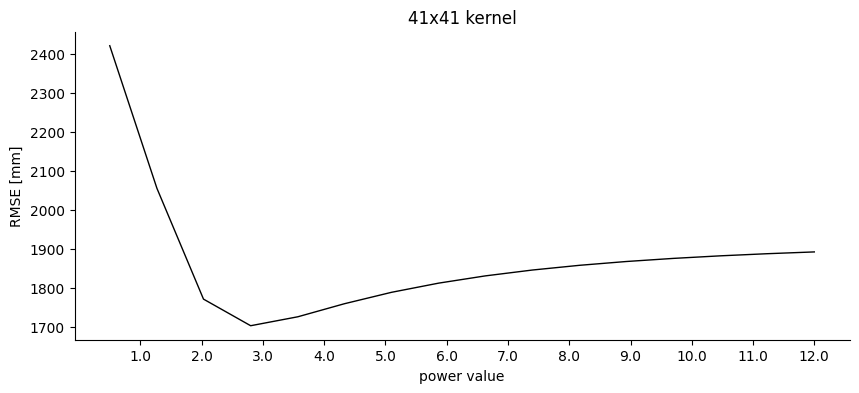

In [ ]:
# ploting training /validation loss
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(1, 1, 1)
power = np.linspace(0.5, 12.0, num=16).round(2)
# taking the average
ax.plot(power, (np.array(rmse_total)/1000), color='black',  linewidth=1.0)
#ax.plot(power, np.sqrt(np.array(mae_total)/1000), linewidth=1.0,color='r', label ='MAE' )

    
plt.xlabel('power value')
plt.ylabel('RMSE [mm]')
# Hide the right and top spines
power = np.linspace(1.0, 12.0, num=12)
p = [1, 3, 5, 7, 9, 11]
ax.set_xticks(power, labels=power)

ax.spines[['right', 'top']].set_visible(False)
plt.title('41x41 kernel')
#plt.savefig('power_rmse', format= 'eps' )
#plt.legend(loc='upper center')

# RMSE computation from IDW interpolation: NYU

In [ ]:
def inverse_distance_weighted(k1, power):
    kernel = np.empty((k1,k1))
    center = np.array((0,0))
    kernel = []
    weights = []
    
    for value in power:
        kernel = []
        for x_axis in np.arange(-(k1-1)/2, (k1+1)/2, 1):
            dist = []
            for y_axis in np.arange((k1-1)/2,-(k1+1)/2, -1):
                d = np.linalg.norm(center - np.array((x_axis, y_axis)))
                if d != 0:
                    weight = 1/(d**value)
                else:
                    weight = 0
                dist.append(weight)
            kernel.append(dist)
            
        # changing to tensor and reshaping it
        kernel_tensor = torch.tensor(np.array(kernel).astype(dtype = np.float32))
        kernel_tensor = kernel_tensor.unsqueeze(0).unsqueeze(1)
    
        # adding the tensor to a list
        weights.append(kernel_tensor)
        
    weights = torch.stack(weights).squeeze(1) # removing the extra channel
    return weights.to(device = 'cuda')

# ==============================================================================================================================================
def evaluate(output, target):
    valid_mask = target > 0

    # convert from meters to mm
    output_mm = 1e3 * output[valid_mask]
    target_mm = 1e3 * target[valid_mask]

    abs_diff = (output_mm - target_mm).abs()

    mse = float((torch.pow(abs_diff, 2)).mean())
    rmse = math.sqrt(mse)
    mae = float(abs_diff.mean())
        
    return rmse, mae

#====================================================================================================================================================
class IDW(nn.Module):
    def __init__(self, w):
        super().__init__()

        self.weight = w

        self.conv1 = nn.Conv2d(1, 16, 41, stride=1, bias = False, padding = 'same', dilation=1)
        self.conv1.weight = nn.Parameter(self.weight, requires_grad=False)
        self.max_pool1 = nn.MaxPool2d(
            41, 
            stride=1, 
            padding=41//2)
        '''
        weight2 = cc(self.weight, output_size=11)
        weight2 = self.layer_two_weights(weight2)
        self.conv2 = nn.Conv2d(8, 8, 11, stride=1, bias = False, padding = 'same', dilation=1)
        self.conv2.weight = nn.Parameter(weight2 , requires_grad=False)
        self.max_pool2 = nn.MaxPool2d(
            11, 
            stride=1, 
            padding=11//2)
        
        weight3 = cc(self.weight, output_size=7)
        weight3 = self.layer_two_weights(weight3)
        self.conv3 = nn.Conv2d(8, 8, 7, stride=1, bias = False, padding = 'same', dilation=1)
        self.conv3.weight = nn.Parameter(weight3 , requires_grad=False)
        self.max_pool3 = nn.MaxPool2d(
            7, 
            stride=1, 
            padding=7//2)
        
        weight4 = cc(self.weight, output_size=5)
        weight4 = self.layer_two_weights(weight4)
        self.conv4 = nn.Conv2d(8, 8, 5, stride=1, bias = False, padding = 'same', dilation=1)
        self.conv4.weight = nn.Parameter(weight4 , requires_grad=False)
        self.max_pool4 = nn.MaxPool2d(
            5, 
            stride=1, 
            padding=5//2)
        
        weight5 = cc(self.weight, output_size=3)
        weight5 = self.layer_two_weights(weight5)
        self.conv5 = nn.Conv2d(8, 8, 3, stride=1, bias = False, padding = 'same', dilation=1)
        self.conv5.weight = nn.Parameter(weight5 , requires_grad=False)
        self.max_pool5 = nn.MaxPool2d(
            3, 
            stride=1, 
            padding=3//2)
        
        '''
    def forward(self, x, mask):
        #mask_multi_channel = torch.ones((1,8,x.shape[2], x.shape[3])).to(device='cuda')
        #for i in range(0,1):
            #mask_multi_channel[i,:] = mask[i,0]
        conv_x = self.conv1(x)
        normalizer = self.conv1(mask)
        normalizer[normalizer==0] = -1
        normalizer = 1/normalizer
        normalizer[normalizer==-1] = 0
        conv_x = conv_x * normalizer
        conv_x = x + (1-mask)*conv_x
        #mask_input= self.max_pool1(mask_multi_channel)
        '''
        conv_x = self.conv2(conv_x)
        normalizer = self.conv2(mask_input)
        normalizer[normalizer==0] = -1
        normalizer = 1/normalizer
        normalizer[normalizer==-1] = 0
        conv_x = conv_x * normalizer
        #conv_x = x + (1-mask)*conv_x
        mask_input= self.max_pool2(mask_input)
        
        conv_x = self.conv3(conv_x)
        normalizer = self.conv3(mask_input)
        normalizer[normalizer==0] = -1
        normalizer = 1/normalizer
        normalizer[normalizer==-1] = 0
        conv_x = conv_x * normalizer
        #conv_x = x + (1-mask)*conv_x
        mask_input= self.max_pool3(mask_input)
        
        conv_x = self.conv4(conv_x)
        normalizer = self.conv4(mask_input)
        normalizer[normalizer==0] = -1
        normalizer = 1/normalizer
        normalizer[normalizer==-1] = 0
        conv_x = conv_x * normalizer
        #conv_x = x + (1-mask)*conv_x
        mask_input= self.max_pool4(mask_input)
        
        conv_x = self.conv5(conv_x)
        normalizer = self.conv5(mask_input)
        normalizer[normalizer==0] = -1
        normalizer = 1/normalizer
        normalizer[normalizer==-1] = 0
        conv_x = conv_x * normalizer
        conv_x = x + (1-mask)*conv_x
        mask_input= self.max_pool5(mask_input)
        #plt.imshow(conv_x[0,0].detach().cpu().numpy())
        '''
        return conv_x
    
    
    def layer_two_weights(self,w):
        weight_init = w.transpose(1,0).to(device = 'cuda')
        zero_weights = torch.zeros_like(torch.empty(8, 8,w.shape[2], w.shape[3]))

        weight_temp = copy.deepcopy(zero_weights)
        for j in range(0,8):
            weight_temp[j,j,:, :] = weight_init[0,j, :, :]
        return weight_temp 


#==================================================================================================================================================
power = np.linspace(0.5, 12.0, num=16).round(2)
weight =  inverse_distance_weighted(41, power)
model = IDW(weight).to(device='cuda')
rmse_total =[]
mae_total = []
img_list = []
with open('/data/nyudepthv2/test.txt' ) as xh:
    lines = xh.readlines()
    for i in range(len(lines)):
        #line_split = str(lines[i]).split('\t')
        path= lines[i].strip()
        h5f = h5py.File(path, 'r')
        label = np.array(h5f['depth'])
        
        samples = [2000]
        num_samples = np.random.choice(samples, 1)[0]
        mask_keep = label > 0
        
        # total number of valid pixels
        n_keep = np.count_nonzero(mask_keep)
        if n_keep == 0:
            mask = mask_keep
        else:
            prob = float(num_samples) / n_keep
            mask=  np.bitwise_and(mask_keep, np.random.uniform(0, 1, label.shape) < prob)
        
        data = np.zeros(label.shape)
        data[mask] = label[mask]
        
            
        data = torch.tensor(data).unsqueeze(0).unsqueeze(0)
        data = data.to(dtype = torch.float32).to(device = 'cuda')
        label = torch.tensor(label).unsqueeze(0).unsqueeze(0).to(dtype = torch.float32).to(device = 'cuda')
    
        mask = torch.tensor(mask).unsqueeze(0).unsqueeze(0).to(dtype = torch.float32).to(device = 'cuda')
        output = model(data, mask)
        
        '''
        sparse = np.squeeze(data1[0, ...]).data.cpu().numpy()
        sparse = depth_colorize(sparse)

        gt = np.squeeze(label[0, ...]).data.cpu().numpy()
        gt = depth_colorize(gt)

        pred  = np.squeeze(output[0, ...]).data.cpu().numpy()
        pred =depth_colorize(pred)
 
        img_list.append(sparse)
        img_list.append(gt)
        img_list.append(pred)

        img_merge1 = np.hstack(img_list)
        img_merge1 = img_merge1.astype('uint8')

        img = cv2.cvtColor(img_merge1, cv2.COLOR_RGB2BGR)
        filename = '/Users/shambelfentemengistu/depth_completion/Datasets/out.png'
        cv2.imwrite(filename, img)

        filename = '/Users/shambelfentemengistu/depth_completion/Datasets/pred.png'
        img = validcrop(output)
        img = np.squeeze(img.data.cpu().numpy())
        img = feature_colorize(img)
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        cv2.imwrite(filename, img)
        
        filename = '/Users/shambelfentemengistu/depth_completion/Datasets/pred_final.png'
        save_depth_as_uint16png_upload(pred, filename)
        '''
       
        for j in range(output.shape[1]):
            #print(output[0,j,:].shape, label.shape)
            if i ==0:
                rmse, mae = evaluate(output[0,j,:].unsqueeze(0).unsqueeze(0),label)
                rmse_total.append(rmse)
                mae_total.append(mae)
            else:
                rmse, mae = evaluate(output[0,j,:].unsqueeze(0).unsqueeze(0),label)
                rmse = rmse_total[j] + rmse
                rmse_total[j] = rmse
                
                mae = mae_total[j] + mae
                mae_total[j] = mae
        

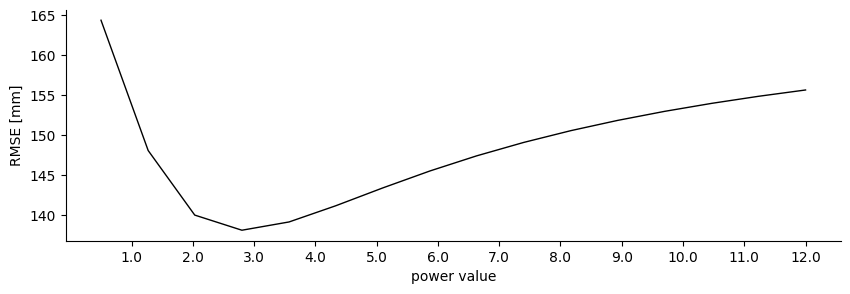

In [ ]:
# ploting training /validation loss
fig = plt.figure(figsize=(10,3))
ax = fig.add_subplot(1, 1, 1)
power = np.linspace(0.5, 12.0, num=16).round(2)
#pixel = np.array(rmse_total).reshape(-1,1)
rmse_norm = np.array(rmse_total)/654
#normalize all values to be between 0 and 1
#rmse_norm = pre.MinMaxScaler().fit_transform(pixel)/654

# taking the average
ax.plot(power, rmse_norm, color='black',  linewidth=1.0)
#ax.plot(power, np.sqrt(np.array(mae_total)/1000), linewidth=1.0,color='r', label ='MAE' )

    
plt.xlabel('power value')
plt.ylabel('RMSE [mm]')
# Hide the right and top spines
power = np.linspace(1.0, 12.0, num=12)
p = [1, 3, 5, 7, 9, 11]
ax.set_xticks(power, labels=power)

ax.spines[['right', 'top']].set_visible(False)
plt.savefig('power_rmse', format= 'eps' )
#plt.legend(loc='upper center')

# kernel size 41 x 41


In [ ]:
points_2000 = [164.40779569, 148.07757339, 139.98883915, 138.09177956, 139.12928502, 141.15277757, 143.39517131, 145.52028111,
       147.4077961 , 149.09467164, 150.57193978, 151.84986749, 152.98805927, 153.99217332, 154.87152519, 155.66605425]

points_3000 = [153.65626925, 133.80766108, 122.20866104, 118.50205855, 118.83427369, 120.59926342, 122.72667629, 124.77855729,
       126.60268267, 128.22640956, 129.64094852, 130.85835454, 131.93765156, 132.88597688, 133.71362864, 134.45926191]

points_5000 = [147.72545457, 124.23585852, 107.78668687, 101.27760134, 100.39442013, 101.60207438, 103.39022863, 105.18583334,
       106.79572234, 108.22852383, 109.47354338, 110.54187138, 111.48635407, 112.31415017, 113.03503443, 113.68322398]

points_10000 = [142.76167598, 115.87704219,  92.87954378,  82.2871058 , 79.70050041,  80.12939178,  81.41951433,  82.82904546,
        84.11959758,  85.27479459,  86.27946374,  87.14066961, 87.90061991,  88.56516386,  89.14247385,  89.66029146]

points_20000 = [138.60991295, 109.84787016,  81.03354079,  66.39337893, 62.46277373,  62.3760855 ,  63.3224932 ,  64.44129389,
        65.47752311,  66.403207  ,  67.20281317,  67.88202103, 68.47519748,  68.98828106,  69.4292752 ,  69.82087606]
points_30000 = [135.49694999, 106.47426831,  75.20886216,  58.34995517, 53.86046386,  53.61303576,  54.42549624,  55.4105963 ,
        56.32135577,  57.12947784,  57.8211027 ,  58.40220083, 58.90359943,  59.33182149,  59.69528639,  60.01422127]

channel =  list(np.linspace(0.5, 12.0, num=16).round(2))
p = ['points_2000']*16
points = np.append(p, [['points_3000']*16,['points_5000']*16, ['points_10000']*16, ['points_20000']*16, ['points_30000']*16])
pixels = np.append(points_2000, [points_3000,points_5000,points_10000, points_20000,points_30000])
#pixel = np.array(pixels).reshape(-1,1)
pixel = np.array(pixels)
#normalize all values to be between 0 and 1
#pixel_norm = pre.MinMaxScaler().fit_transform(pixel)
channels = channel*6

In [ ]:
df1 = pd.DataFrame()
df1['power'] = channels
df1['RMSE'] = pixel
df1['point'] = points

fig = px.line(df1, x="power", y="RMSE", color='point', title="kernel size 41 x 41")
fig.update_layout(
    xaxis = dict(
        tickmode = 'linear',
        tick0 = 0.5,
        dtick = 1
    )
)

fig.show()

# kernel size 31 x 31

In [ ]:
points_2000 = [223.23403529, 216.05970806, 213.3822689 , 213.24614385, 214.19764064, 215.4851737 , 216.8328277 , 218.10248032,
       219.2401972 , 220.27043375, 221.1852824 , 221.98711676, 222.70982992, 223.35426304, 223.9239534 , 224.44296643]

points_3000 = [148.41505489, 135.82355083, 129.88095154, 128.62119463, 129.54543836, 131.20792768, 133.04001472, 134.78284515,
       136.3394904 , 137.73841239, 138.96968533, 140.03943336,  140.99572882, 141.8420269 , 142.58512493, 143.25803032]

points_5000 = [130.70041379, 113.75205621, 103.68070369, 100.33959214,  100.49411805, 101.92529251, 103.7019433 , 105.4365033 ,
       106.98904201, 108.3768912 , 109.58926632, 110.63449066,   111.56209771, 112.37757462, 113.08939548, 113.73059436]

points_10000 = [123.59897457, 102.98558584,  87.4049276 ,  80.76180497,  79.46184996,  80.21437684,  81.57408404,  82.99407082,
        84.28475183,  85.43975857,  86.44525979,  87.30802021,  88.06991155,  88.73651562,  89.31584447,  89.83562745]

points_20000 = [118.60835364,  95.76682794,  74.94343103,  64.77901062, 62.14593107,  62.33831592,  63.33925007,  64.46727802,
        65.50456248,  66.43009447,  67.22952676,  67.90869178,  68.50193786,  69.01517545,  69.45638243,  69.84824242]
points_30000 = [115.63014912,  92.2479693 ,  69.00889683,  56.77922299,  53.48908208,  53.45340829,  54.29737683,  55.2856765 ,
        56.19622194,  57.00397879,  57.69530166,  58.27607925, 58.77708422,  59.204839  ,  59.56778587,  59.88615818]

channel =  list(np.linspace(0.5, 12.0, num=16).round(2))
p = ['points_2000']*16
points = np.append(p, [['points_3000']*16,['points_5000']*16, ['points_10000']*16, ['points_20000']*16, ['points_30000']*16])
pixels = np.append(points_2000, [points_3000,points_5000,points_10000, points_20000,points_30000])

pixel = np.array(pixels)
channels = channel*6

In [ ]:
df1 = pd.DataFrame()
df1['power'] = channels
df1['RMSE'] = pixel
df1['point'] = points

fig = px.line(df1, x="power", y="RMSE", color='point', title="kernel size 31 x 31")
fig.update_layout(
    xaxis = dict(
        tickmode = 'linear',
        tick0 = 0.5,
        dtick = 1
    )
)

fig.show()

# kernel size 21 x 21

In [ ]:
points_2000 = [733.95754438, 733.10498324, 732.89571504, 732.97708988,
       733.1711385 , 733.39488363, 733.62104031, 733.8334831 ,
       734.02541549, 734.20134594, 734.35967084, 734.50026956,
       734.62857541, 734.7443111 , 734.84770275, 734.94279889]

points_3000 = [386.10688092, 383.85805152, 383.15258166, 383.22025854,
       383.60481055, 384.08359951, 384.57804909, 385.04523621,
       385.46725124, 385.85304311, 386.19893195, 386.5048441 ,
       386.78286868, 387.03266504, 387.25498833, 387.45876029]

points_5000 = [153.32857003, 146.24894525, 143.25619571, 142.82398723,
       143.53496944, 144.62434526, 145.79893742, 146.91659922,
       147.92103114, 148.83051059, 149.63694473, 150.34226803,
       150.97646544, 151.54054408, 152.03794395, 152.48997377]

points_10000 = [103.13501968,  90.04053553,  82.10694461,  79.40758567,
        79.46509486,  80.55454769,  81.94096961,  83.3106782 ,
        84.54515555,  85.65304772,  86.62268121,  87.45893738,
        88.20058685,  88.85169084,  89.41902324,  89.9290566 ]

points_20000 = [95.86920411, 80.25009586, 68.14054348, 62.8375621 , 61.80959775,
       62.41910114, 63.51692092, 64.66336714, 65.70310232, 66.62908568,
       67.42944264, 68.11006637, 68.70507721, 69.22015168, 69.66312038,
       70.0566551 ]
points_30000 = [92.67784035, 76.20979471, 61.86224822, 54.81064649, 53.10153309,
       53.43103903, 54.35131626, 55.35279395, 56.26435221, 57.0711636 ,
       57.76141157, 58.34123346, 58.84136305, 59.26830419, 59.63049472,
       59.9481448 ]

channel =  list(np.linspace(0.5, 12.0, num=16).round(2))
p = ['points_2000']*16
points = np.append(p, [['points_3000']*16,['points_5000']*16, ['points_10000']*16, ['points_20000']*16, ['points_30000']*16])
pixels = np.append(points_2000, [points_3000,points_5000,points_10000, points_20000,points_30000])
#pixel = np.array(pixels).reshape(-1,1)
pixel = np.array(pixels)
#normalize all values to be between 0 and 1
#pixel_norm = pre.MinMaxScaler().fit_transform(pixel)
channels = channel*6


In [ ]:
df1 = pd.DataFrame()
df1['channel'] = channels
df1['RMSE'] = pixel
df1['point'] = points

fig = px.line(df1, x="channel", y="RMSE", color='point', title="kernel size 21 x 21")
fig.update_layout(
    xaxis = dict(
        tickmode = 'linear',
        tick0 = 0.5,
        dtick = 1
    )
)

fig.show()

# plotting the RMSE error with different sparsity level

# depth points selcted with uniform probability

In [2]:
RMSE = np.array([[1064,1118, 1232, 1441, 1884],[1037, 1096, 1216, 1441, 1922],[1314, 1379, 1518, 1785, 2445],[1089, 1160, 1302, 1558, 2094]])
RMSE_pd = pd.DataFrame(RMSE, columns=['0%', '20%', '40%', '60%', '80%'])
sparsity = ['0%', '20%', '40%', '60%', '80%', '0%', '20%', '40%', '60%', '80%', '0%', '20%', '40%', '60%', '80%', '0%', '20%', '40%', '60%', '80%']
error = np.log2(np.array([1064,1118, 1232, 1441, 1884,1037, 1096, 1216, 1441, 1922,1314, 1379, 1518, 1785, 2445,1089, 1160, 1302, 1558, 2094]))
method = ['MS-Net', 'MS-Net','MS-Net', 'MS-Net', 'MS-Net', 'MS-Net:IDW','MS-Net:IDW', 'MS-Net:IDW', 'MS-Net:IDW', 'MS-Net:IDW','SparseConv', 'SparseConv', 'SparseConv', 'SparseConv','SparseConv', 'SParseConv:IDW','SParseConv:IDW','SParseConv:IDW','SParseConv:IDW','SParseConv:IDW']
df=pd.DataFrame()
df['Sparsity'] = sparsity 
df['RMSE'] = error  
df['method'] = method
fig = px.line(df, x='Sparsity', y='RMSE', color='method', markers=True,  width=600, height=300,
               color_discrete_map={
                 'MS-Net': "red",
                 'MS-Net:IDW': "black",
                 'SparseConv': 'blue',
                 'SParseConv:IDW': 'green'
                 
             })
fig.update_layout(legend=dict(
    yanchor="top",
    y=0.99,
    xanchor="left",
    x=0.01
))
#pio.write_image(fig, 'rmse.png',scale=6, width=1080, height=1080)
fig.write_image("rmse.png") 
fig.show()

In [ ]:

RMSE_pd = pd.DataFrame(RMSE, columns=['0%', '20%', '40%', '60%', '80%'])
sparsity = ['0%', '20%', '40%', '60%', '80%', '0%', '20%', '40%', '60%', '80%', '0%', '20%', '40%', '60%', '80%', '0%', '20%', '40%', '60%', '80%']
error = np.log2(np.array([311,327, 365, 452, 690,281, 301, 342, 423, 638,409, 438, 516, 679, 1032,287, 311, 355, 445, 679]))
method = ['MS-Net', 'MS-Net','MS-Net', 'MS-Net', 'MS-Net', 'MS-Net:IDW','MS-Net:IDW', 'MS-Net:IDW', 'MS-Net:IDW', 'MS-Net:IDW','SparseConv', 'SparseConv', 'SparseConv', 'SparseConv','SparseConv', 'SParseConv:IDW','SParseConv:IDW','SParseConv:IDW','SParseConv:IDW','SParseConv:IDW']
df=pd.DataFrame()
df['Sparsity'] = sparsity 
df['MAE'] = error  
df['method'] = method
fig = px.line(df, x='Sparsity', y='MAE', color='method', markers=True,  width=600, height=300,
               color_discrete_map={
                 'MS-Net': "red",
                 'MS-Net:IDW': "black",
                 'SparseConv': 'darkblue',
                 'SParseConv:IDW': 'green'
                 
             })
fig.update_layout(legend=dict(
    yanchor="top",
    y=0.99,
    xanchor="left",
    x=0.01
))
fig.write_image("mae.png") 
fig.show()

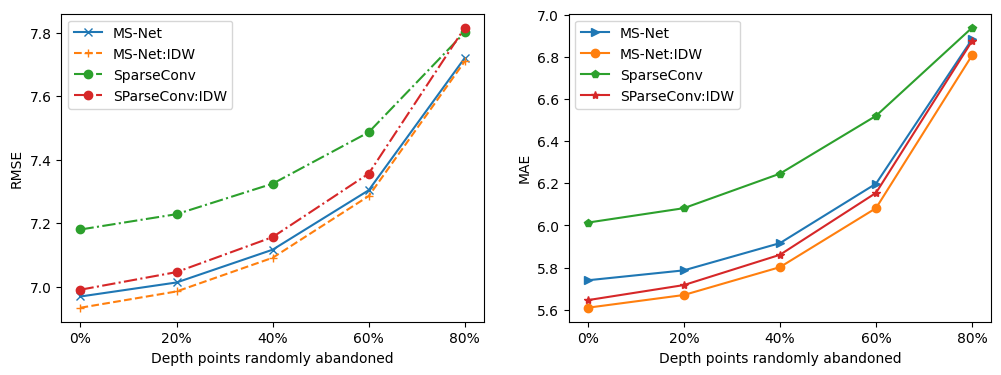

In [22]:
fig, ax = plt.subplots(nrows = 1, ncols=2,figsize=(12, 4))
MS_Net = [1064,1112, 1233, 1487, 2256]
MS_idw = [1027, 1081, 1202, 1460, 2232]
sparseConv = [1314, 1379, 1518, 1785, 2445]
sparseConv_idw = [1087, 1149, 1283, 1567, 2481]
sparsity = ['0%', '20%', '40%', '60%', '80%']
#plt.figure(figsize=(6,4))
ax[0].plot(sparsity, np.log(MS_Net), 'x-', label='MS-Net')
ax[0].plot(sparsity, np.log(MS_idw), '+--', label='MS-Net:IDW')
ax[0].plot(sparsity, np.log(sparseConv), 'o-.', label='SparseConv')
ax[0].plot(sparsity, np.log(sparseConv_idw ), 'o-.', label='SParseConv:IDW')
ax[0].set_xlabel("Depth points randomly abandoned", fontsize=10)
ax[0].set_ylabel("RMSE")
ax[0].legend(loc="best")


MS_Net = [311,326, 371, 492, 977]
MS_idw = [273, 290, 331, 438, 905]
sparseConv = [409, 438, 516, 679, 1032]
sparseConv_idw = [283, 304, 351, 471, 969]
sparsity = ['0%', '20%', '40%', '60%', '80%']
#plt.figure(figsize=(6,4))
ax[1].plot(sparsity, np.log(MS_Net), marker = '>', label='MS-Net')
ax[1].plot(sparsity, np.log(MS_idw), marker = 'o', label='MS-Net:IDW')
ax[1].plot(sparsity, np.log(sparseConv), marker = 'p', label='SparseConv')
ax[1].plot(sparsity, np.log(sparseConv_idw ), marker = '*', label='SParseConv:IDW')
ax[1].set_xlabel("Depth points randomly abandoned", fontsize=10)
ax[1].set_ylabel("MAE")
ax[1].legend(loc="best")
#ax[1].savefig('mae.png')
#fig.supxlabel("Depth points randomly abandoned", fontsize=8)
plt.savefig('error.png')

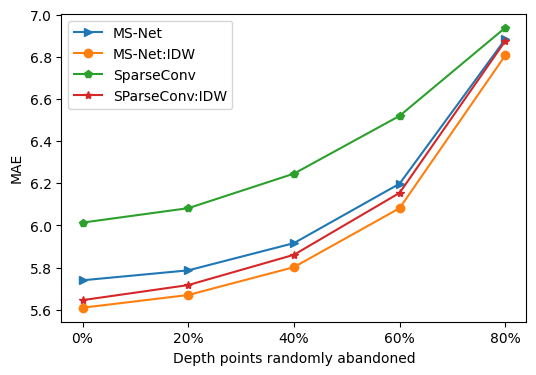

In [8]:
MS_Net = [311,326, 371, 492, 977]
MS_idw = [273, 290, 331, 438, 905]
sparseConv = [409, 438, 516, 679, 1032]
sparseConv_idw = [283, 304, 351, 471, 969]
sparsity = ['0%', '20%', '40%', '60%', '80%']
#plt.figure(figsize=(6,4))
plt.plot(sparsity, np.log(MS_Net), marker = '>', label='MS-Net')
plt.plot(sparsity, np.log(MS_idw), marker = 'o', label='MS-Net:IDW')
plt.plot(sparsity, np.log(sparseConv), marker = 'p', label='SparseConv')
plt.plot(sparsity, np.log(sparseConv_idw ), marker = '*', label='SParseConv:IDW')
plt.xlabel("Depth points randomly abandoned")
plt.ylabel("MAE")
plt.legend(loc="best")
plt.savefig('mae.png')

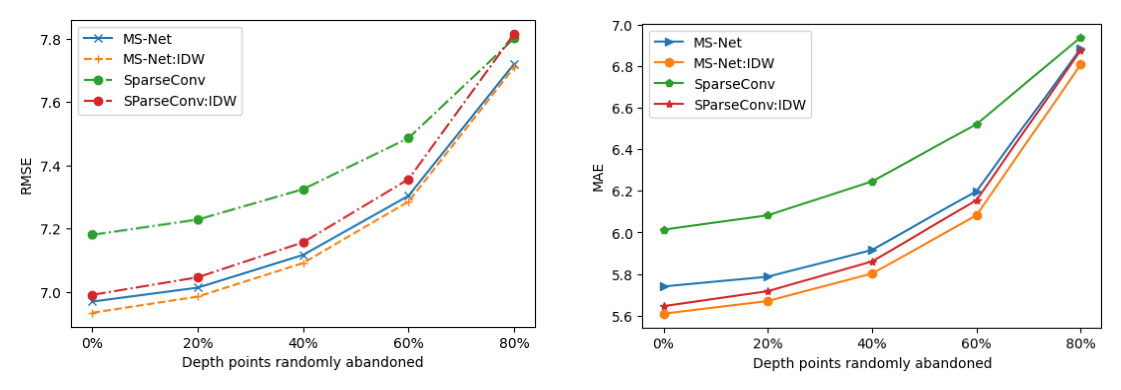

In [9]:
# concatenating the two images
fig = plt.figure(figsize=(12,4))
row = 1
col = 2
fig.add_subplot(row, col, 1)
rmse = plt.imread('rmse.png')
plt.imshow(rmse)
#fig.axes[0].set_xlabel("Depth points randomly abandoned")
plt.axis('off')
plt.tight_layout()
fig.add_subplot(row, col, 2)
mae = plt.imread('mae.png')
plt.imshow(mae)
plt.axis('off')
plt.tight_layout()
plt.savefig('output.png')

In [ ]:
# sparsity based on depth points selected on different propablities

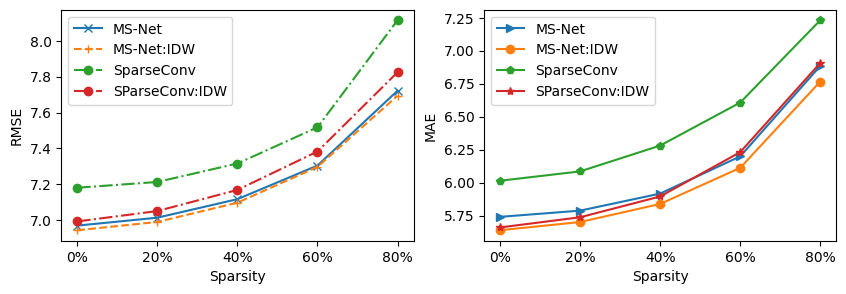

In [103]:
fig = plt.figure(figsize=(10,3))

# RMSE errors
MS_Net = [1064,1112, 1233, 1487, 2256]   
MS_idw = [1037, 1086, 1209, 1476, 2194]         
sparseConv = [1314, 1357, 1504, 1840, 3342] # )))))))))))
sparseConv_idw = [1089, 1154, 1298, 1608, 2501]  
sparsity = ['0%', '20%', '40%', '60%', '80%']
ax1 = fig.add_subplot(1, 2, 1)
plt.plot(sparsity, np.log(MS_Net), 'x-', label='MS-Net')
plt.plot(sparsity, np.log(MS_idw), '+--', label='MS-Net:IDW')
plt.plot(sparsity, np.log(sparseConv), 'o-.', label='SparseConv')
plt.plot(sparsity, np.log(sparseConv_idw ), 'o-.', label='SParseConv:IDW')
plt.xlabel("Sparsity")
plt.ylabel("RMSE")

plt.legend(loc="best")




# MAE errors
MS_Net = [311,326, 371, 492, 977]  
MS_idw = [281, 299, 343, 451, 868]  
sparseConv = [409, 439, 534, 740, 1382] # )))))))))))
sparseConv_idw = [287, 310, 363, 508, 999]  
sparsity = ['0%', '20%', '40%', '60%', '80%']
fig.add_subplot(122, sharex = ax1)
plt.plot(sparsity, np.log(MS_Net), marker = '>', label='MS-Net')
plt.plot(sparsity, np.log(MS_idw), marker = 'o', label='MS-Net:IDW')
plt.plot(sparsity, np.log(sparseConv), marker = 'p', label='SparseConv')
plt.plot(sparsity, np.log(sparseConv_idw ), marker = '*', label='SParseConv:IDW')
plt.ylabel("MAE")
plt.xlabel("Sparsity")
plt.legend(loc="best")
#fig.supxlabel('Depth points randomly abandoned')
#plt.savefig('result.png')

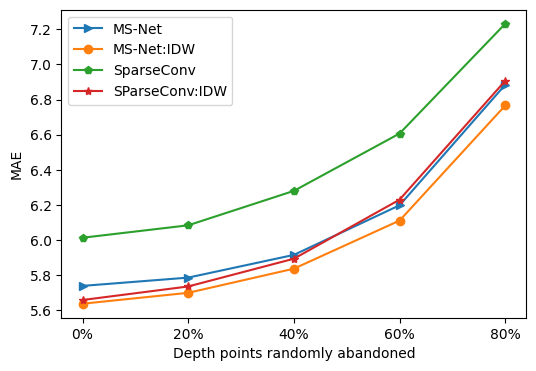

In [4]:
# MAE errors
MS_Net = [311,326, 371, 492, 977]  
MS_idw = [281, 299, 343, 451, 868]  
sparseConv = [409, 439, 534, 740, 1382] # )))))))))))
sparseConv_idw = [287, 310, 363, 508, 999]  
sparsity = ['0%', '20%', '40%', '60%', '80%']
plt.figure(figsize=(6,4))
plt.plot(sparsity, np.log(MS_Net), marker = '>', label='MS-Net')
plt.plot(sparsity, np.log(MS_idw), marker = 'o', label='MS-Net:IDW')
plt.plot(sparsity, np.log(sparseConv), marker = 'p', label='SparseConv')
plt.plot(sparsity, np.log(sparseConv_idw ), marker = '*', label='SParseConv:IDW')
plt.xlabel("Depth points randomly abandoned")
plt.ylabel("MAE")
plt.legend(loc="best")
plt.savefig('mae.png')

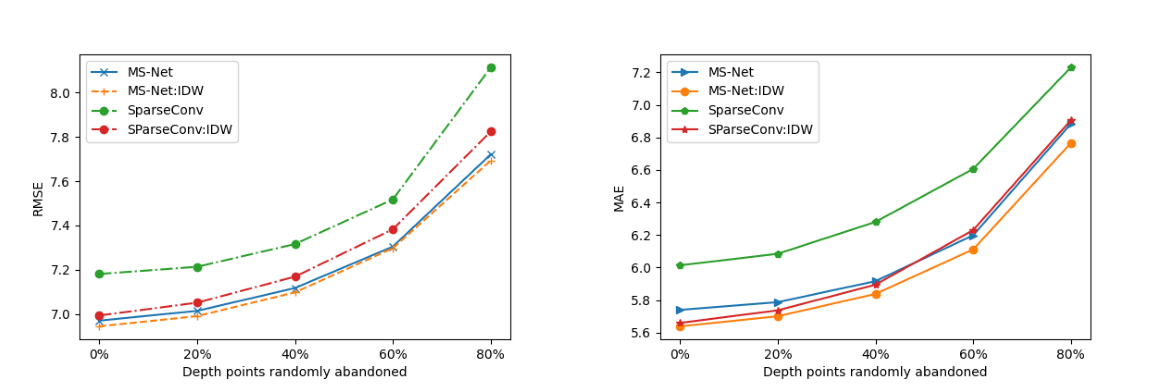

In [5]:
# concatenating the two images
fig = plt.figure(figsize=(12,4))
row = 1
col = 2
fig.add_subplot(row, col, 1)
rmse = plt.imread('rmse.png')
plt.imshow(rmse)
#fig.axes[0].set_xlabel("Depth points randomly abandoned")
plt.axis('off')
plt.tight_layout()
fig.add_subplot(row, col, 2)
mae = plt.imread('mae.png')
plt.imshow(mae)
plt.axis('off')
plt.tight_layout()
plt.savefig('output.png')

In [ ]:
import os
for (root,dirs,files) in os.walk('C:/Users/HP/HMS-Net/', topdown=True):
    if files:
        if 'groundtruth' in root:
            with open('C:/Users/HP/HMS-Net/gt.txt', 'a+') as f:   
                root = root.replace(os.sep, '/')
                for i in(files):
                    f.write(root + '/' + i)
                    f.write("\n")
                f.close()     
        if 'rowdata' in root:
            with open('C:/Users/HP/HMS-Net/rd.txt', 'a+') as f:                
                root = root.replace(os.sep, '/')
                for i in(files):
                    f.write(root + '/' + i)
                    f.write("\n")
                f.close()    

In [ ]:
# concatenating the two text files rowise
combine =[]
gt_path = 'C:/Users/HP/HMS-Net/gt.txt'
rd_path = 'C:/Users/HP/HMS-Net/rd.txt'
train_path = 'C:/Users/HP/HMS-Net/train.txt'
with open(gt_path ) as xh:
    with open(rd_path ) as yh:
        with open(train_path,"w") as zh:
            #Read first file
            xlines = xh.readlines()
            #Read second file
            ylines = yh.readlines()
            #Combine content of both lists
            combine = list(zip(xlines,ylines))
            #Write to third file
            for i in range(len(xlines)):
                line = ylines[i].strip() + '\t' + xlines[i]
                zh.write(line)

# Generating a sparse depth map

In [ ]:
# sparse is generated taking the whole depth  map at once
# reading the depth map
path = '/Users/shambelfentemengistu/depth_completion/Datasets/train/rawdata/00000000029.png'
d = cv2.imread(path,  cv2.IMREAD_ANYDEPTH)
d = d.astype(float)/256.0
d = np.pad(d, ((2,1),(0,0)), mode = 'constant')

# creating an array of all ones for mask
array_ones = np.ones((d.shape[0], d.shape[1]))

# Number of elements to replace, 60% of elements
num_replaced = int(d.shape[0] * d.shape[1] - (d.shape[0] * d.shape[1])* (40/100))

# Random (x, y) coordinates
indices_x = np.random.randint(0.0, array_ones .shape[0], num_replaced)
indices_y = np.random.randint(0.0, array_ones .shape[1], num_replaced)

array_ones [indices_x, indices_y] = 0
sparse_data = array_ones * d

In [ ]:
np.count_nonzero(sparse_data==0.0)/(sparse_data.shape[0]*sparse_data.shape[1])*100

97.2871882694749

In [ ]:
print(np.count_nonzero(d==0.0))

450560


# Performing sampling the mask according to the sampling rate, for each patch in the depth map

In [ ]:
# sparse is generated for each 9x18 patches
# reading the depth map
path = '/Users/shambelfentemengistu/depth_completion/Datasets/train/rawdata/00000000029.png'
d = cv2.imread(path,  cv2.IMREAD_ANYDEPTH)
d = d.astype(float)/256.0
# padding the depth map to make it evenly divisible for the patch
d = np.pad(d, ((2,1),(0,0)), mode = 'constant')

# generating the mask
mask= (d>0).astype(float)

for i in np.arange(0,mask.shape[0], 9, dtype = int):
    for j in np.arange(0, mask.shape[1], 18, dtype=int):
        # slicing a patch of size 9x18 from the mask
        patch = mask[i:i+9, j:j+18]
        #count the number of ones in the patch and set 40% of them to zero, i.e, selecting only 60% of them(60% rate)
        num_replaced = int(np.count_nonzero(patch) - np.count_nonzero(patch)* (40/100))  # 9x18 is the patch size
        # storing iindices all ones in the patch
        indices = np.where(patch ==1)

        # if all the elements in the patch are zero, do nothing
        if len(indices[0]) !=0: 
            indices_x = np.random.choice(indices[0], num_replaced)
            indices_y = np.random.choice(indices[0], num_replaced)

            patch[indices_x, indices_y] = 0
            mask[i:i+9, j:j+18] = patch       
print(mask)


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
# sparse is generated for each 9x18 patches
# reading the depth map
path = '/Users/shambelfentemengistu/depth_completion/Datasets/train/rawdata/00000000029.png'
data = cv2.imread(path,  cv2.IMREAD_ANYDEPTH)
##data=Image.fromarray(data)
#data = f.center_crop(data, output_size=(352, 1242))

In [ ]:
data =  data[(data.shape[0]-352):, :]

In [ ]:
data.shape

(352, 1242)

# IDW Interpolation

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as tf
import cv2
import numpy as np
from PIL import Image
import os
import json
import torch.nn.functional as F
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10,15)


In [ ]:
def inverse_distance_weighted():
    kernel = np.empty((41,41))
    center = np.array((0,0))
    power = [3] # 3,4,5,6,7,8
    kernel = []
    weights = []
    
    for value in power:
        kernel = []
        for x_axis in np.arange(-20, 21, 1):
            dist = []
            for y_axis in np.arange(20,-21, -1):
                d = np.linalg.norm(center - np.array((x_axis, y_axis)))
                if d != 0:
                    weight = 1/(d**value)
                else:
                    weight = 0
                dist.append(weight)
            kernel.append(dist)
            
        # changing to tensor and reshaping it
        #kernel_tensor = torch.tensor(np.array(kernel).astype(float))
        kernel_tensor = torch.tensor(np.array(kernel).astype(float))
        kernel_tensor = kernel_tensor.unsqueeze(0).unsqueeze(1)
    
        # adding the tensor to a list
        weights.append(kernel_tensor)
        
    weights = torch.stack(weights).squeeze(1) # removing the extra channel
    return weights

In [ ]:

def pre_processing():
    path1 = 'D:/Dataset/val_selection_cropped/groundtruth_depth/2011_10_03_drive_0047_sync_groundtruth_depth_0000000791_image_03.png'
    path = 'D:/Dataset/val_selection_cropped/velodyne_raw/2011_10_03_drive_0047_sync_velodyne_raw_0000000791_image_03.png'
    #c = Image.open(path)

    d1 = cv2.imread(path, cv2.IMREAD_ANYDEPTH)
    data2 = d1.astype(float)/256.0

    d = cv2.imread(path1, cv2.IMREAD_ANYDEPTH)
    data = d.astype(float)/256.0
    #data=Image.fromarray(data)

    #image = cv2.cvtColor(src=image, code=cv2.COLOR_BGR2GRAY)

    # transforming into tensor
    x_data = torch.tensor(data)
    
    mask_d = (x_data==0).to(dtype = torch.float64)
    mask_input = (x_data>0).to(dtype = torch.float64).unsqueeze(0).unsqueeze(0)

    # adding channels
    data1 = torch.unsqueeze(x_data, 0)
    data1 = torch.unsqueeze(data1, 0)

    return mask_d, mask_input, data1, data2, data, d,d1


0
[[1 0 3 0 0 1 1]
 [1 0 0 0 0 2 1]
 [5 0 7 0 1 2 1]]


In [ ]:
class IDW(nn.Module):
    def __init__(self, w):
        super().__init__()

        self.weight = w

        self.conv = nn.Conv2d(1, 1, 7, stride=1, bias = False, padding = 'same', dilation=1)
        self.conv.weight = nn.Parameter(self.weight, requires_grad=False)
        

    def forward(self, x, mask_input):
        conv_x = self.conv(x)
        mask_out = self.conv(mask_input).squeeze(0).squeeze(0).numpy()
        mask_inverse = np.divide(1, mask_out, out=np.zeros_like(mask_out), where=mask_out!=0)
        conv_x = conv_x * mask_inverse
        activated_x = F.relu(conv_x)
        return conv_x, activated_x
weight =  inverse_distance_weighted()
mask_d, mask_input, data1, data2, data, d,d1= pre_processing()
model = IDW(weight)
output, output_activated = model(data1, mask_input)
tar = (data2>0).astype(float)
out = torch.squeeze(output, 0)
out = torch.squeeze(out, 0).detach().numpy()

out_m = mask_d.numpy()*out
out_f = data + out_m

In [ ]:
cmap = plt.cm.jet
cmap2 = plt.cm.nipy_spectral

In [ ]:
import numpy as np
import matplotlib.pyplot as plot
import torch

import torch.nn as nn
import torch
import torchvision.transforms as tf
import matplotlib.pyplot as plt
from matplotlib import cm
import imageio
import numpy as np

def inverse_distance_weighted(k1, power):
    kernel = np.empty((k1,k1))
    center = np.array((0,0))
    kernel = []
    weights = []
    
    for value in power:
        kernel = []
        for x_axis in np.arange(-(k1-1)/2, (k1+1)/2, 1):
            dist = []
            for y_axis in np.arange((k1-1)/2,-(k1+1)/2, -1):
                d = np.linalg.norm(center - np.array((x_axis, y_axis)))
                if d != 0:
                    weight = 1/(d**value)
                else:
                    weight = 0
                dist.append(weight)
            kernel.append(dist)
            
        # changing to tensor and reshaping it
        kernel_tensor = torch.tensor(np.array(kernel).astype(dtype = np.float32))
        kernel_tensor = kernel_tensor.unsqueeze(0).unsqueeze(1)
    
        # adding the tensor to a list
        weights.append(kernel_tensor)
        
    weights = torch.stack(weights).squeeze(1) # removing the extra channel
    return weights

In [ ]:

#from inverse_distance_weight import inverse_distance_weighted
#power = [3, 3.2, 3.5, 3.8, 4, 4.2, 4.5, 4.6, 4.8, 5, 5.2, 5.3, 5.5, 5.8, 6, 6.2] 
power = [2, 2.2 ,2.5, 2.8, 3, 3.2, 3.5] 
weights = inverse_distance_weighted(41, power)


class inverseDistWeight(nn.Module):
    def __init__(self):
        super().__init__()

        # convolution layer for Inverse distance weighted interpolation
        self.inverse_dist_weight = nn.Conv2d(
            1,
            7,
            kernel_size=31,
            padding = 'same',
            bias=False) 

        self.inverse_dist_weight.weight = nn.Parameter(
                                 data = weights, 
                                 requires_grad = False)
    def forward(self, x, mask):
        epsilon = 1.0e-12
        # computing channelwise multiplication with IDW
        idw_f = self.inverse_dist_weight(x)
        idw_norm = 1/(self.inverse_dist_weight(mask) + epsilon)
                     
        idw_f = idw_f * idw_norm 
        #idw_final = x + (1-mask)*idw_f
        return  idw_f

In [ ]:
path = '/data/Datasets/val/rawdata/00000000034.png'
    #c = Image.open(path)

d1 = cv2.imread(path, cv2.IMREAD_ANYDEPTH)
data = d1.astype(float)/256.0

# transforming into tensor
x_data = torch.tensor(data).to(dtype = torch.float32)
    
#mask_input = (x_data>0).to(dtype = torch.float64).unsqueeze(0).unsqueeze(0)

    # adding channels
data1 = torch.unsqueeze(x_data, 0)
data1 = torch.unsqueeze(data1, 0)
mask_input = (data1>0).float()
print(data1.dtype)
idw = inverseDistWeight()
idw_f = idw(data1, mask_input)

torch.float32


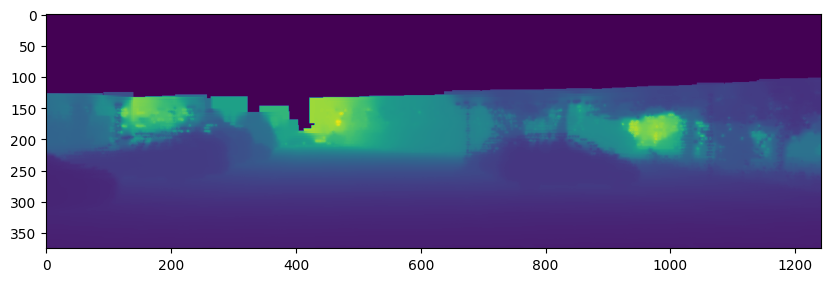

In [ ]:
plt.imshow(idw_f[0][1].numpy())

In [ ]:
import torchvision.transforms as tf
from torchvision.utils import make_grid
import torchvision
img = torchvision.transforms.ToPILImage()(idw_f[0][1])

plt.imsave('/home/shambel/SparConv/' + 'test'+ '.png', idw_f[0][1], cmap = 'Greys')

In [ ]:
fig = plt.figure(figsize=(15, 3))
# setting values to rows and column variables
rows = 1
columns = 7

for i in range(1, 8):
    # Adds a subplot at the 1st position
    fig.add_subplot(1, 7, i)
  
    # showing image
    plt.imshow(idw_f[0][i-1], cmap = 'Greys')
    plt.axis('off')
plt.savefig('/home/shambel/SparConv/' + 'test'+ '.png', bbox_inches='tight' )
plt.close()



In [ ]:
import pandas as pd
channel = pd.read_csv('/home/shambel/SparConv/channel_average/channel.csv')
channel.round(1)

,32.57837,0.0033399223,56.453682,21.983244,0.0046145758,439.97952,0.003378825,0.0035698302,0.004275178,0.005196635,0.0066596554,0.011014716,0.38394243,355.02954,62.687958,30.861532
0,627.5,44.4,65.3,63.1,5.8,3.4,2.4,0.8,0.5,2.4,3.8,2.8,2.8,4.9,155.1,15.0
1,148.4,97.7,45.1,23.2,0.5,2.1,55.6,154.2,61.4,10.8,5.7,6.8,149.8,104.0,106.3,28.4
2,896.8,27.3,8.3,4.2,3.8,3.6,3.5,3.3,3.4,3.4,3.6,4.1,4.4,4.4,4.3,21.5


In [ ]:
min_patch = []
max_patch = []
with open('/data//Datasets/test.txt' ) as xh:
    lines = xh.readlines()
    for k in range(len(lines)):
        min = 32*32
        max  = 0
        line_split = str(lines[k]).split('\t')
        path1= line_split[0].strip()
        path2 = line_split[1].strip()

        data = cv2.imread(path1,  cv2.IMREAD_ANYDEPTH)
        data = data.astype(float)/256.0
        data = data[(data.shape[0]-256):, :]  
        
        np.random.seed(42)
        mask = (data>0).astype(float)
        for i in np.arange(0,mask.shape[0], 32, dtype = int):
            for j in np.arange(0, mask.shape[1], 32, dtype=int):
                # slicing a patch of size 9x18 from the mask
                patch = mask[i:(i+32), j:(j+32)]
                #count the number of ones in the patch and abandon 40% of depth points, i.e, selecting only 60% of them(60% rate)
                num_replaced = np.count_nonzero(patch)
                if num_replaced>max:
                    max = num_replaced
                if num_replaced<min:
                    min = num_replaced
                    
        max_patch.append(max)
        min_patch.append(min)
                
                
total_pixes = 32*32
max = np.array(max_patch).sum()/1000
min = np.array(min_patch).sum()/1000
print((max/total_pixes)*100)
print((min/total_pixes)*100)
            
                

13.43447265625
0.009863281250000001


In [66]:
path1 = '/home/shambel/SparConv/featuremaps_training/softmaxV/201.png'
data1 = plt.imread(path1, cv2.IMREAD_ANYDEPTH)

path2 = '/home/shambel/SparConv/featuremaps_training/softmaxV/2010.png'
data2 = plt.imread(path2,  cv2.IMREAD_ANYDEPTH)

path3 = '/home/shambel/SparConv/featuremaps_training/softmaxV/2020.png'
data3 = plt.imread(path3,  cv2.IMREAD_ANYDEPTH)

path4 = '/home/shambel/SparConv/featuremaps_training/softmaxV/2030.png'
data4 = plt.imread(path4,  cv2.IMREAD_ANYDEPTH)

path5 = '/home/shambel/SparConv/featuremaps_training/softmaxV/2040.png'
data5 = plt.imread(path5,  cv2.IMREAD_ANYDEPTH)

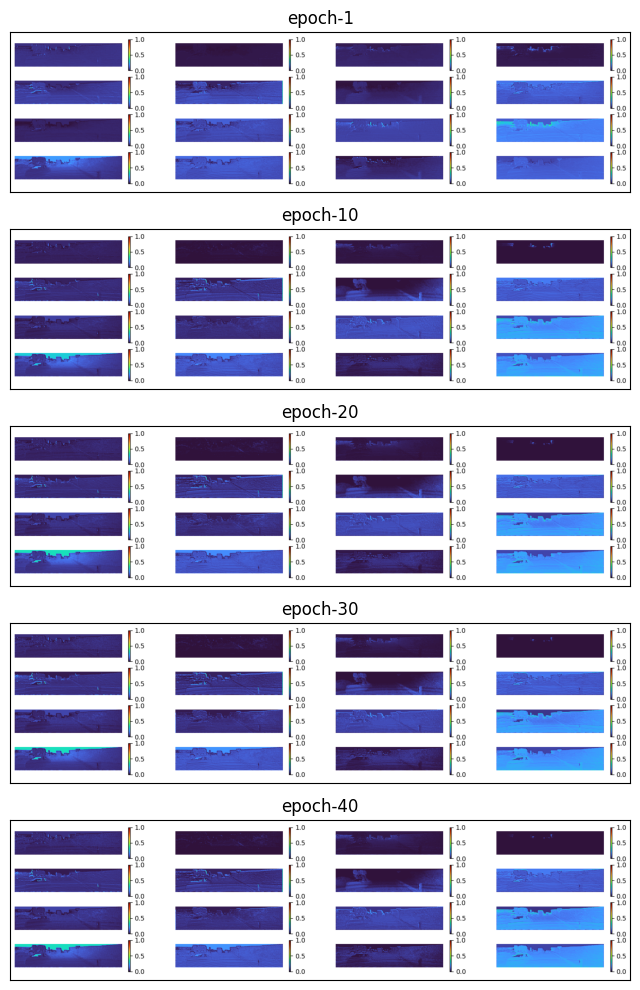

In [67]:
fig, ax = plt.subplots(nrows = 5, ncols=1,figsize=(8, 10), sharex=True)

#plt.figure(figsize=(6,4))
ax[0].imshow(data1)
ax[0].set_title('epoch-1')
ax[1].imshow(data2)
ax[1].set_title('epoch-10')
ax[2].imshow(data3)
ax[2].set_title('epoch-20')
ax[3].imshow(data4)
ax[3].set_title('epoch-30')
ax[4].imshow(data5)
ax[4].set_title('epoch-40')
#ax[0].set_xlabel("Depth points randomly abandoned", fontsize=10)
#ax[0].set_ylabel("RMSE")
#ax[0].legend(loc="best")
for ax in ax:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

In [68]:
path1 = '/home/shambel/HMS_nyu/featuremaps/softmaxV_1000/1.png'
data1 = plt.imread(path1, cv2.IMREAD_ANYDEPTH)

path2 = '/home/shambel/HMS_nyu/featuremaps/softmaxV_5000/1.png'
data2 = plt.imread(path2,  cv2.IMREAD_ANYDEPTH)

path3 = '/home/shambel/HMS_nyu/featuremaps/softmaxV_10000/1.png'
data3 = plt.imread(path3,  cv2.IMREAD_ANYDEPTH)

path4 = '/home/shambel/HMS_nyu/featuremaps/softmaxV_30000/1.png'
data4 = plt.imread(path4,  cv2.IMREAD_ANYDEPTH)


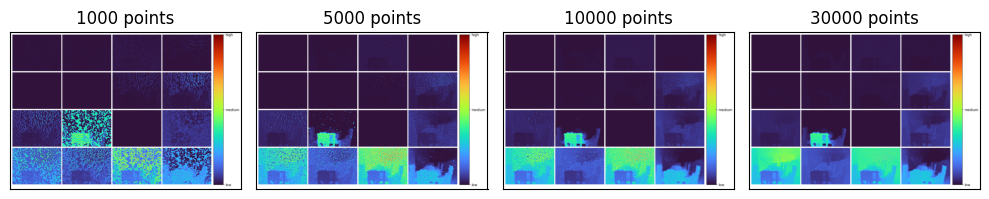

In [71]:
fig, ax = plt.subplots(nrows = 1, ncols=4,figsize=(10, 8), sharex=True)

ax[0].imshow(data1)
ax[0].set_title('1000 points')
ax[1].imshow(data2)
ax[1].set_title('5000 points')
ax[2].imshow(data3)
ax[2].set_title('10000 points')
ax[3].imshow(data4)
ax[3].set_title('30000 points')

for ax in ax:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()



In [76]:
path1 = '/home/shambel/SparConv_nyu/1000points.png'
data1 = plt.imread(path1, cv2.IMREAD_ANYDEPTH)

path2 = '/home/shambel/SparConv_nyu/5000points.png'
data2 = plt.imread(path2,  cv2.IMREAD_ANYDEPTH)

path3 = '/home/shambel/SparConv_nyu/10000points.png'
data3 = plt.imread(path3,  cv2.IMREAD_ANYDEPTH)

path4 = '/home/shambel/SparConv_nyu/20000points.png'
data4 = plt.imread(path4,  cv2.IMREAD_ANYDEPTH)


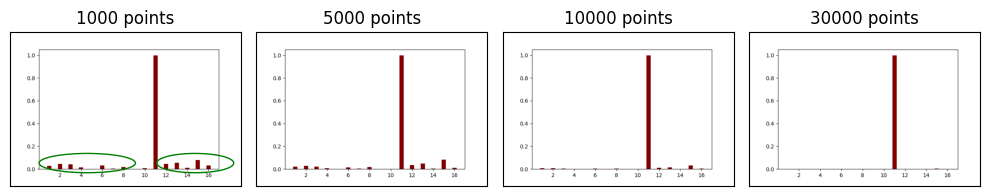

In [107]:
fig, ax = plt.subplots(nrows = 1, ncols=4,figsize=(10, 8), sharex=True)

ax[0].imshow(data1)
ax[0].set_title('1000 points')
elipse1 = patches.Ellipse((200,340), 250,50, linewidth = 1.0, edgecolor = 'green', facecolor = 'none')
elipse2 = patches.Ellipse((480,340), 200,50, linewidth = 1.0, edgecolor = 'green', facecolor = 'none')
ax[0].add_patch(elipse1)
ax[0].add_patch(elipse2)
ax[1].imshow(data2)
ax[1].set_title('5000 points')
ax[2].imshow(data3)
ax[2].set_title('10000 points')
ax[3].imshow(data4)
ax[3].set_title('30000 points')

for ax in ax:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

